In [ ]:
## standard imports
import numpy as np
import scipy
import matplotlib.pyplot as plt
from copy import deepcopy
from tqdm import tqdm

In [ ]:
from scipy.stats import uniform, norm, gaussian_kde

In [ ]:
!pip install dynesty

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.9/102.9 kB 3.6 MB/s eta 0:00:00


In [ ]:
from dynesty import NestedSampler

In [ ]:
!pip install corner

In [ ]:
import corner

In [ ]:
M = 100
X = np.linspace(-1,1,M)
alpha_true = 0.5
beta_true = 1.5
Y_true = alpha_true + beta_true*X

In [ ]:
sigma_noise = 0.5
noise_obs = np.random.normal(0,sigma_noise,M)
Y_obs = Y_true + noise_obs

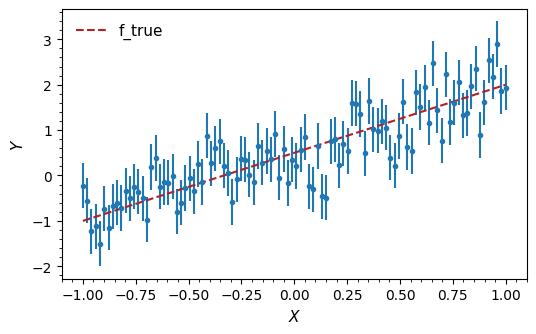

In [ ]:
plt.figure(figsize=(6,3.5))

plt.errorbar(X,Y_obs,yerr=sigma_noise,marker='o',linestyle='',markersize=3)
plt.plot(X,Y_true,color='firebrick',linestyle='--',linewidth=1.5,label='f_true')

plt.legend(fontsize=11,frameon=False)

plt.xlabel(r'$X$',fontsize=11)
plt.ylabel(r'$Y$',fontsize=11)

plt.minorticks_on()

plt.show()

# Linear model

In [ ]:
## priors

def ptform(u):
  xmin = np.array([-5,-4])
  xmax = np.array([5,4])
  theta = uniform.ppf(u,loc=xmin,scale=xmax-xmin)
  return theta

def model(x,alpha,beta):
  out = alpha + beta*x
  return out

def loglike(theta):
  Y_pred = model(X,*theta)
  out = np.sum(norm.logpdf(x=Y_obs,loc=Y_pred,scale=sigma_noise))
  return out

In [ ]:
ndim = 2
nlive = 1000
sampler = NestedSampler(loglike, ptform, ndim, nlive=nlive)
sampler.run_nested()
res = sampler.results
samples = res.samples_equal()

8187it [00:26, 310.85it/s, +1000 | bound: 7 | nc: 1 | ncall: 43699 | eff(%): 21.516 | loglstar:   -inf < -69.393 <    inf | logz: -77.340 +/-  0.083 | dlogz:  0.001 >  1.009]


In [ ]:
a,b,c = np.quantile(samples,q=[0.05,0.5,0.95],axis=0)
print('alpha = %.2f^{+%.2f}_{%.2f}'%(b[0],c[0]-b[0],a[0]-b[0]))
print('beta = %.2f^{+%.2f}_{%.2f}'%(b[1],c[1]-b[1],a[1]-b[1]))

alpha = 0.51^{+0.08}_{-0.08}
beta = 1.39^{+0.14}_{-0.14}


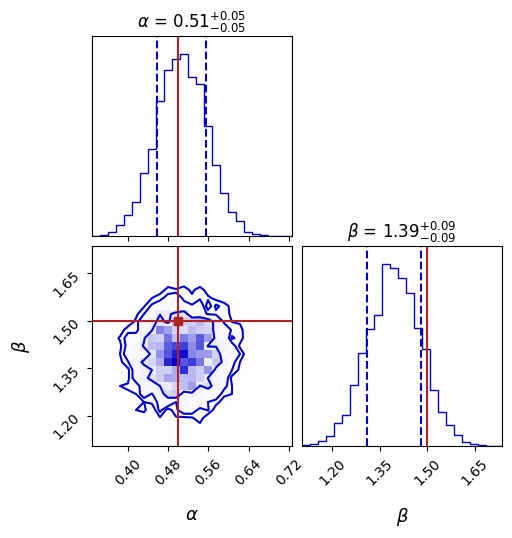

In [ ]:
## corner plot of the posterior
## https://matplotlib.org/stable/gallery/color/named_colors.html

labels = [r'$\alpha$',r'$\beta$']
truths = [alpha_true,beta_true]

hist2d_kwargs = {'plot_datapoints':False,'fill_contours':False,
                 'levels':[0.68,0.90,0.95]}

fig = corner.corner(samples,bins=25,color='mediumblue',\
                    truths=truths,truth_color='firebrick',\
                    labels=labels,label_kwargs={'fontsize':13},\
                    quantiles = [0.16,0.84],\
                    show_titles=True,title_quantiles=[0.16,0.5,0.84],\
                    hist_kwargs={'density':True},\
                    **hist2d_kwargs,\
                    )

plt.show()

In [ ]:
# build the model predictive distribution

num_samples = len(samples)
yp = np.zeros((num_samples,M))
for i in range(num_samples):
  yp[i] = model(X,*samples[i])

yp_low, yp_med, yp_high = np.quantile(yp,q=[0.05,0.5,0.95],axis=0)

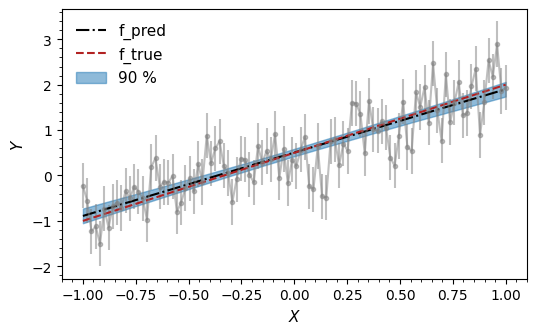

In [ ]:
plt.figure(figsize=(6,3.5))

plt.errorbar(X,Y_obs,yerr=sigma_noise,color='grey',alpha=0.5,marker='o',linestyle='-',markersize=3)

plt.plot(X,yp_med,color='k',linestyle='-.',linewidth=1.5,label='f_pred')
plt.plot(X,Y_true,color='firebrick',linestyle='--',linewidth=1.5,label='f_true')

plt.fill_between(X,yp_low,yp_high,color='C0',alpha=0.5,label='90 %')

plt.legend(fontsize=11,frameon=False)

plt.xlabel(r'$X$',fontsize=11)
plt.ylabel(r'$Y$',fontsize=11)

plt.minorticks_on()

plt.show()

In [ ]:
# build the posterior predictive distribution

num_samples = len(samples)
yp = np.zeros((num_samples,M))
for i in range(num_samples):
  yp[i] = model(X,*samples[i]) + np.random.normal(0,sigma_noise)

yp_low, yp_med, yp_high = np.quantile(yp,q=[0.05,0.5,0.95],axis=0)

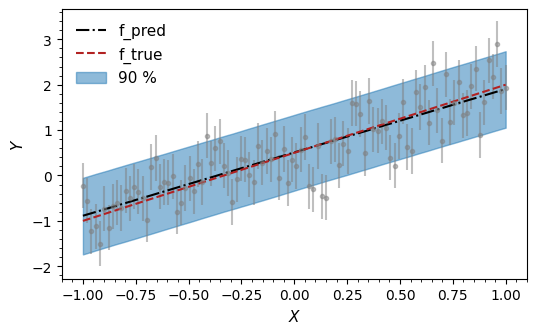

In [ ]:
plt.figure(figsize=(6,3.5))

plt.errorbar(X,Y_obs,yerr=sigma_noise,color='grey',alpha=0.5,marker='o',linestyle='',markersize=3)

plt.plot(X,yp_med,color='k',linestyle='-.',linewidth=1.5,label='f_pred')
plt.plot(X,Y_true,color='firebrick',linestyle='--',linewidth=1.5,label='f_true')

plt.fill_between(X,yp_low,yp_high,color='C0',alpha=0.5,label='90 %')

plt.legend(fontsize=11,frameon=False)

plt.xlabel(r'$X$',fontsize=11)
plt.ylabel(r'$Y$',fontsize=11)

plt.minorticks_on()

plt.show()

# Quadratic model

In [ ]:
## priors

def ptform(u):
  xmin = np.array([-5,-4])
  xmax = np.array([5,4])
  theta = uniform.ppf(u,loc=xmin,scale=xmax-xmin)
  return theta

def model2(x,alpha,beta):
  out = alpha + beta*x**2
  return out

def loglike(theta):
  Y_pred = model2(X,*theta)
  out = np.sum(norm.logpdf(x=Y_obs,loc=Y_pred,scale=sigma_noise))
  return out

In [ ]:
ndim = 2
nlive = 1000
sampler = NestedSampler(loglike, ptform, ndim, nlive=nlive)
sampler.run_nested()
res2 = sampler.results
samples2 = res2.samples_equal()

5237it [00:19, 273.33it/s, +1000 | bound: 3 | nc: 1 | ncall: 38721 | eff(%): 16.535 | loglstar:   -inf < -204.193 <    inf | logz: -209.192 +/-  0.063 | dlogz:  0.001 >  1.009]


In [ ]:
a,b,c = np.quantile(samples2,q=[0.05,0.5,0.95],axis=0)
print('alpha = %.2f^{+%.2f}_{%.2f}'%(b[0],c[0]-b[0],a[0]-b[0]))
print('beta = %.2f^{+%.2f}_{%.2f}'%(b[1],c[1]-b[1],a[1]-b[1]))

alpha = 0.76^{+0.37}_{-0.35}
beta = -0.37^{+0.79}_{-0.83}


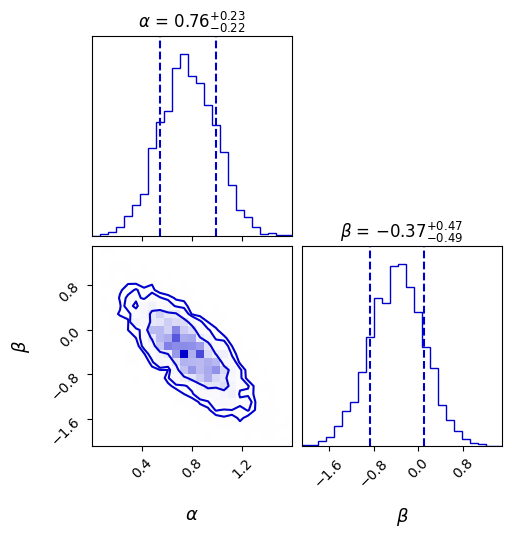

In [ ]:
## corner plot of the posterior
## https://matplotlib.org/stable/gallery/color/named_colors.html

labels = [r'$\alpha$',r'$\beta$']
truths = [alpha_true,beta_true]

hist2d_kwargs = {'plot_datapoints':False,'fill_contours':False,
                 'levels':[0.68,0.90,0.95]}

fig = corner.corner(samples2,bins=25,color='mediumblue',\
                    #truths=truths,truth_color='firebrick',\
                    labels=labels,label_kwargs={'fontsize':13},\
                    quantiles = [0.16,0.84],\
                    show_titles=True,title_quantiles=[0.16,0.5,0.84],\
                    hist_kwargs={'density':True},\
                    **hist2d_kwargs,\
                    )

plt.show()

In [ ]:
# build the model predictive distribution

num_samples = len(samples2)
yp = np.zeros((num_samples,M))
for i in range(num_samples):
  yp[i] = model2(X,*samples2[i])

yp_low, yp_med, yp_high = np.quantile(yp,q=[0.05,0.5,0.95],axis=0)

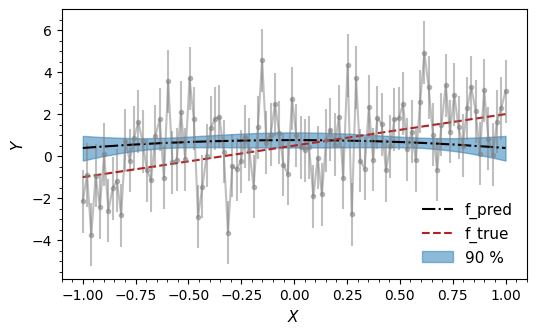

In [ ]:
plt.figure(figsize=(6,3.5))

plt.errorbar(X,Y_obs,yerr=sigma_noise,color='grey',alpha=0.5,marker='o',linestyle='-',markersize=3)

plt.plot(X,yp_med,color='k',linestyle='-.',linewidth=1.5,label='f_pred')
plt.plot(X,Y_true,color='firebrick',linestyle='--',linewidth=1.5,label='f_true')

plt.fill_between(X,yp_low,yp_high,color='C0',alpha=0.5,label='90 %')

plt.legend(fontsize=11,frameon=False)

plt.xlabel(r'$X$',fontsize=11)
plt.ylabel(r'$Y$',fontsize=11)

plt.minorticks_on()

plt.show()

In [ ]:
# build the posterior predictive distribution

num_samples = len(samples2)
yp = np.zeros((num_samples,M))
for i in range(num_samples):
  yp[i] = model2(X,*samples2[i]) + np.random.normal(0,sigma_noise)

yp_low, yp_med, yp_high = np.quantile(yp,q=[0.05,0.5,0.95],axis=0)

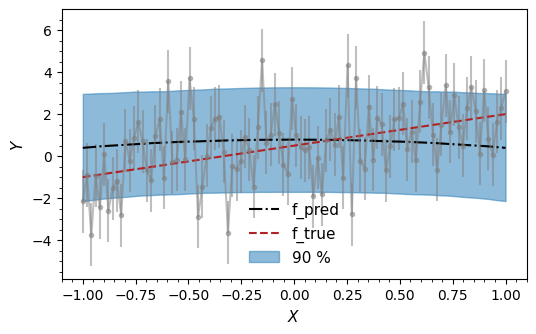

In [ ]:
plt.figure(figsize=(6,3.5))

plt.errorbar(X,Y_obs,yerr=sigma_noise,color='grey',alpha=0.5,marker='o',linestyle='-',markersize=3)

plt.plot(X,yp_med,color='k',linestyle='-.',linewidth=1.5,label='f_pred')
plt.plot(X,Y_true,color='firebrick',linestyle='--',linewidth=1.5,label='f_true')

plt.fill_between(X,yp_low,yp_high,color='C0',alpha=0.5,label='90 %')

plt.legend(fontsize=11,frameon=False)

plt.xlabel(r'$X$',fontsize=11)
plt.ylabel(r'$Y$',fontsize=11)

plt.minorticks_on()

plt.show()

In [ ]:
logB = res.logz[-1]-res2.logz[-1]
print(logB)

13.674276411970709


# Parabolic model

In [ ]:
## priors

def ptform(u):
  xmin = np.array([-5,-4,-1])
  xmax = np.array([5,4,1])
  theta = uniform.ppf(u,loc=xmin,scale=xmax-xmin)
  return theta

def model2(x,alpha,beta,gamma):
  out = alpha + beta*x + gamma*x**2
  return out

def loglike(theta):
  Y_pred = model2(X,*theta)
  out = np.sum(norm.logpdf(x=Y_obs,loc=Y_pred,scale=sigma_noise))
  return out

In [ ]:
ndim = 3
nlive = 1000
sampler = NestedSampler(loglike, ptform, ndim, nlive=nlive)
sampler.run_nested()
res2 = sampler.results
samples2 = res2.samples_equal()

9768it [00:28, 340.08it/s, +1000 | bound: 11 | nc: 1 | ncall: 47041 | eff(%): 23.388 | loglstar:   -inf < -68.251 <    inf | logz: -77.912 +/-  0.102 | dlogz:  0.001 >  1.009]


In [ ]:
a,b,c = np.quantile(samples2,q=[0.05,0.5,0.95],axis=0)
print('alpha = %.2f^{+%.2f}_{%.2f}'%(b[0],c[0]-b[0],a[0]-b[0]))
print('beta = %.2f^{+%.2f}_{%.2f}'%(b[1],c[1]-b[1],a[1]-b[1]))
print('gamma = %.2f^{+%.2f}_{%.2f}'%(b[2],c[2]-b[2],a[2]-b[2]))

alpha = 0.42^{+0.12}_{-0.12}
beta = 1.39^{+0.14}_{-0.14}
gamma = 0.25^{+0.27}_{-0.28}


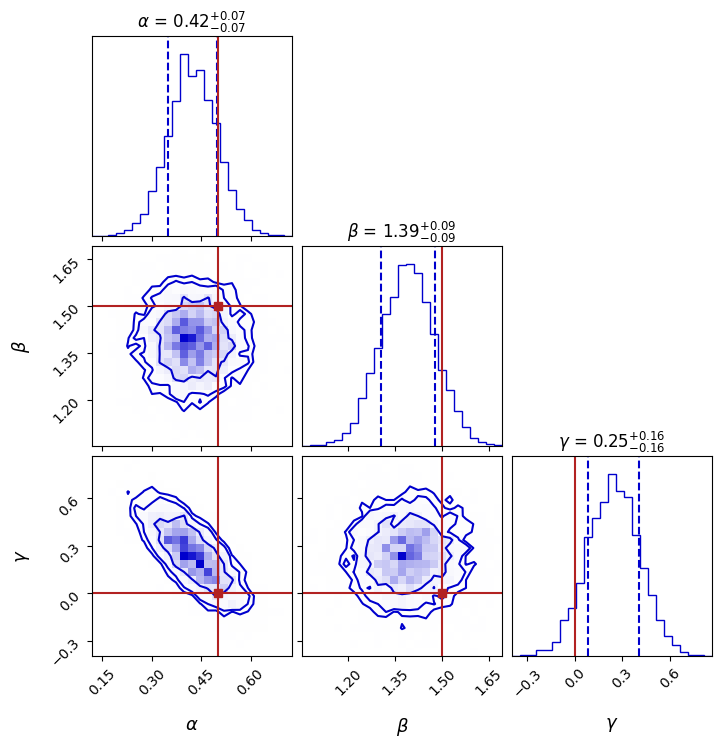

In [ ]:
## corner plot of the posterior
## https://matplotlib.org/stable/gallery/color/named_colors.html

labels = [r'$\alpha$',r'$\beta$',r'$\gamma$']
truths = [alpha_true,beta_true,0.0]

hist2d_kwargs = {'plot_datapoints':False,'fill_contours':False,
                 'levels':[0.68,0.90,0.95]}

fig = corner.corner(samples2,bins=25,color='mediumblue',\
                    truths=truths,truth_color='firebrick',\
                    labels=labels,label_kwargs={'fontsize':13},\
                    quantiles = [0.16,0.84],\
                    show_titles=True,title_quantiles=[0.16,0.5,0.84],\
                    hist_kwargs={'density':True},\
                    **hist2d_kwargs,\
                    )

plt.show()

In [ ]:
# build the model predictive distribution

num_samples = len(samples2)
yp = np.zeros((num_samples,M))
for i in range(num_samples):
  yp[i] = model2(X,*samples2[i])

yp_low, yp_med, yp_high = np.quantile(yp,q=[0.05,0.5,0.95],axis=0)

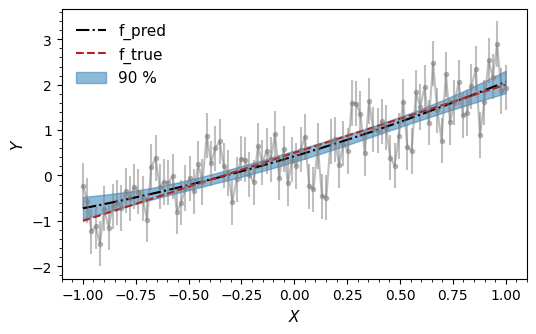

In [ ]:
plt.figure(figsize=(6,3.5))

plt.errorbar(X,Y_obs,yerr=sigma_noise,color='grey',alpha=0.5,marker='o',linestyle='-',markersize=3)

plt.plot(X,yp_med,color='k',linestyle='-.',linewidth=1.5,label='f_pred')
plt.plot(X,Y_true,color='firebrick',linestyle='--',linewidth=1.5,label='f_true')

plt.fill_between(X,yp_low,yp_high,color='C0',alpha=0.5,label='90 %')

plt.legend(fontsize=11,frameon=False)

plt.xlabel(r'$X$',fontsize=11)
plt.ylabel(r'$Y$',fontsize=11)

plt.minorticks_on()

plt.show()

In [ ]:
# build the posterior predictive distribution

num_samples = len(samples2)
yp = np.zeros((num_samples,M))
for i in range(num_samples):
  yp[i] = model2(X,*samples2[i]) + np.random.normal(0,sigma_noise)

yp_low, yp_med, yp_high = np.quantile(yp,q=[0.05,0.5,0.95],axis=0)

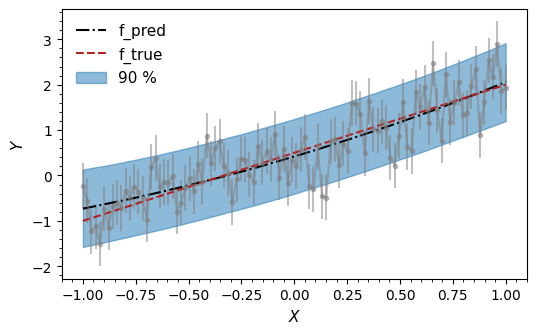

In [ ]:
plt.figure(figsize=(6,3.5))

plt.errorbar(X,Y_obs,yerr=sigma_noise,color='grey',alpha=0.5,marker='o',linestyle='-',markersize=3)

plt.plot(X,yp_med,color='k',linestyle='-.',linewidth=1.5,label='f_pred')
plt.plot(X,Y_true,color='firebrick',linestyle='--',linewidth=1.5,label='f_true')

plt.fill_between(X,yp_low,yp_high,color='C0',alpha=0.5,label='90 %')

plt.legend(fontsize=11,frameon=False)

plt.xlabel(r'$X$',fontsize=11)
plt.ylabel(r'$Y$',fontsize=11)

plt.minorticks_on()

plt.show()

In [ ]:
logB = res.logz[-1]-res2.logz[-1]
print(logB)

0.5719895518433447


In [ ]:
np.exp(logB)

np.float64(1.7717886124078834)

### Savage-Dickey ratio

In [ ]:
gamma_samples = samples2[:,2]

In [ ]:
kde = gaussian_kde(gamma_samples, bw_method=0.2)

In [ ]:
kde_samples = kde.resample(size=len(gamma_samples))[0]
kde_samples.shape

(10768,)

In [ ]:
x = np.linspace(-0.5,1,1000)
y = kde.pdf(x)

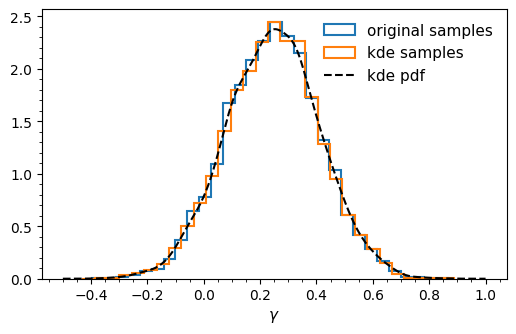

In [ ]:
plt.figure(figsize=(6,3.5))

plt.hist(gamma_samples,bins=30,histtype='step',density=True,linewidth=1.5,label='original samples')
plt.hist(kde_samples,bins=30,histtype='step',density=True,linewidth=1.5,label='kde samples')
plt.plot(x,y,linewidth=1.5,color='k',linestyle='--',label='kde pdf')

plt.minorticks_on()

plt.legend(fontsize=11,frameon=False)

plt.xlabel(r'$\gamma$',fontsize=11)

plt.show()

In [ ]:
xmin = -1
xmax = 1
prior = uniform(loc=xmin,scale=xmax-xmin)

In [ ]:
log_SD = kde.logpdf(0) - prior.logpdf(0)
print(log_SD)

[0.45087396]


# Parabolic model with bounded prior

In [ ]:
## priors

def ptform(u):
  xmin = np.array([-5,-4,0.2])
  xmax = np.array([5,4,1])
  theta = uniform.ppf(u,loc=xmin,scale=xmax-xmin)
  return theta

def model2(x,alpha,beta,gamma):
  out = alpha + beta*x + gamma*x**2
  return out

def loglike(theta):
  Y_pred = model2(X,*theta)
  out = np.sum(norm.logpdf(x=Y_obs,loc=Y_pred,scale=sigma_noise))
  return out

In [ ]:
ndim = 3
nlive = 1000
sampler = NestedSampler(loglike, ptform, ndim, nlive=nlive)
sampler.run_nested()
res2 = sampler.results
samples2 = res2.samples_equal()

9264it [00:33, 274.67it/s, +1000 | bound: 13 | nc: 1 | ncall: 49011 | eff(%): 21.378 | loglstar:   -inf < -68.258 <    inf | logz: -77.381 +/-  0.097 | dlogz:  0.001 >  1.009]


In [ ]:
a,b,c = np.quantile(samples2,q=[0.05,0.5,0.95],axis=0)
print('alpha = %.2f^{+%.2f}_{%.2f}'%(b[0],c[0]-b[0],a[0]-b[0]))
print('beta = %.2f^{+%.2f}_{%.2f}'%(b[1],c[1]-b[1],a[1]-b[1]))
#print('gamma = %.2f^{+%.2f}_{%.2f}'%(b[2],c[2]-b[2],a[2]-b[2]))
print('gamma <= %.2f'%(np.quantile(samples2[:,2],q=0.9)))

alpha = 0.39^{+0.10}_{-0.11}
beta = 1.39^{+0.14}_{-0.14}
gamma <= 0.50


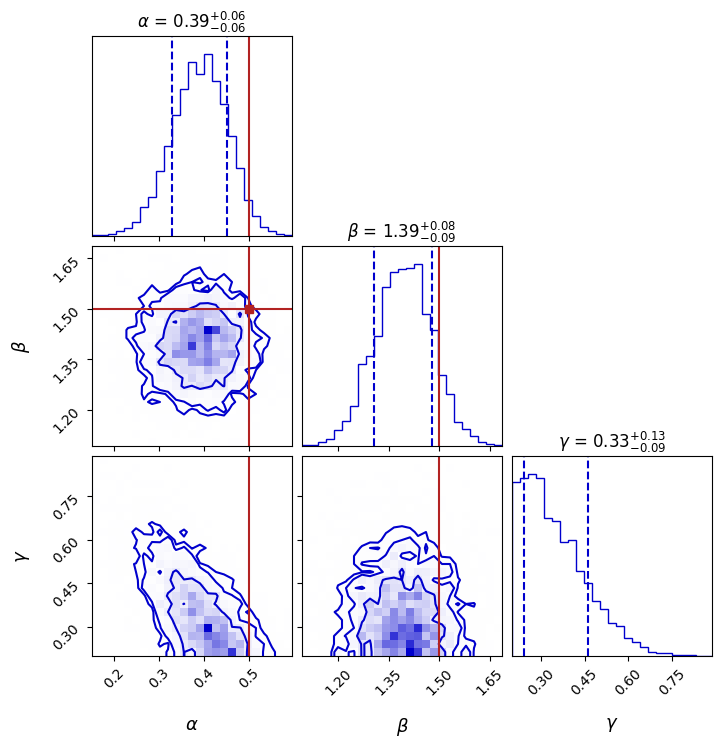

In [ ]:
## corner plot of the posterior
## https://matplotlib.org/stable/gallery/color/named_colors.html

labels = [r'$\alpha$',r'$\beta$',r'$\gamma$']
truths = [alpha_true,beta_true,0.0]

hist2d_kwargs = {'plot_datapoints':False,'fill_contours':False,
                 'levels':[0.68,0.90,0.95]}

fig = corner.corner(samples2,bins=25,color='mediumblue',\
                    truths=truths,truth_color='firebrick',\
                    labels=labels,label_kwargs={'fontsize':13},\
                    quantiles = [0.16,0.84],\
                    show_titles=True,title_quantiles=[0.16,0.5,0.84],\
                    hist_kwargs={'density':True},\
                    **hist2d_kwargs,\
                    )

plt.show()

In [ ]:
# build the model predictive distribution

num_samples = len(samples2)
yp = np.zeros((num_samples,M))
for i in range(num_samples):
  yp[i] = model2(X,*samples2[i])

yp_low, yp_med, yp_high = np.quantile(yp,q=[0.05,0.5,0.95],axis=0)

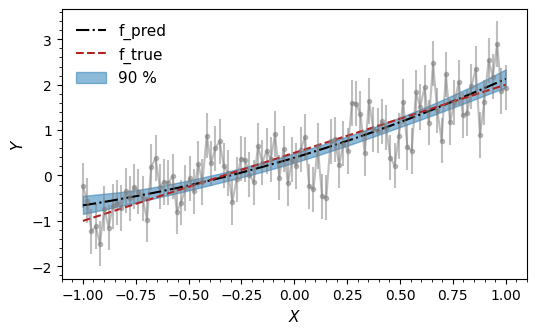

In [ ]:
plt.figure(figsize=(6,3.5))

plt.errorbar(X,Y_obs,yerr=sigma_noise,color='grey',alpha=0.5,marker='o',linestyle='-',markersize=3)

plt.plot(X,yp_med,color='k',linestyle='-.',linewidth=1.5,label='f_pred')
plt.plot(X,Y_true,color='firebrick',linestyle='--',linewidth=1.5,label='f_true')

plt.fill_between(X,yp_low,yp_high,color='C0',alpha=0.5,label='90 %')

plt.legend(fontsize=11,frameon=False)

plt.xlabel(r'$X$',fontsize=11)
plt.ylabel(r'$Y$',fontsize=11)

plt.minorticks_on()

plt.show()

In [ ]:
# build the posterior predictive distribution

num_samples = len(samples2)
yp = np.zeros((num_samples,M))
for i in range(num_samples):
  yp[i] = model2(X,*samples2[i]) + np.random.normal(0,sigma_noise)

yp_low, yp_med, yp_high = np.quantile(yp,q=[0.05,0.5,0.95],axis=0)

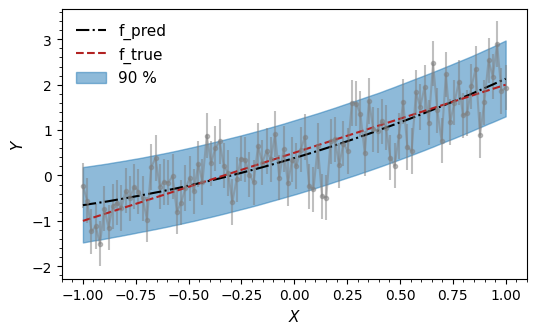

In [ ]:
plt.figure(figsize=(6,3.5))

plt.errorbar(X,Y_obs,yerr=sigma_noise,color='grey',alpha=0.5,marker='o',linestyle='-',markersize=3)

plt.plot(X,yp_med,color='k',linestyle='-.',linewidth=1.5,label='f_pred')
plt.plot(X,Y_true,color='firebrick',linestyle='--',linewidth=1.5,label='f_true')

plt.fill_between(X,yp_low,yp_high,color='C0',alpha=0.5,label='90 %')

plt.legend(fontsize=11,frameon=False)

plt.xlabel(r'$X$',fontsize=11)
plt.ylabel(r'$Y$',fontsize=11)

plt.minorticks_on()

plt.show()

In [ ]:
logB = res.logz[-1]-res2.logz[-1]
print(logB)

0.04085783567542478


### Savage-Dickey ratio

In [ ]:
gamma_samples = samples2[:,2]

In [ ]:
kde = gaussian_kde(gamma_samples)#, bw_method=0.2)

In [ ]:
kde_samples = kde.resample(size=len(gamma_samples))[0]
kde_samples.shape

(10264,)

In [ ]:
x = np.linspace(0,1,1000)
y = kde.pdf(x)

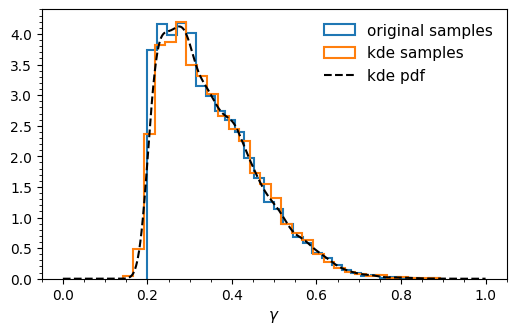

In [ ]:
plt.figure(figsize=(6,3.5))

plt.hist(gamma_samples,bins=30,histtype='step',density=True,linewidth=1.5,label='original samples')
plt.hist(kde_samples,bins=30,histtype='step',density=True,linewidth=1.5,label='kde samples')
plt.plot(x,y,linewidth=1.5,color='k',linestyle='--',label='kde pdf')

plt.minorticks_on()

plt.legend(fontsize=11,frameon=False)

plt.xlabel(r'$\gamma$',fontsize=11)

plt.show()

In [ ]:
xmin = 0
xmax = 1
prior = uniform(loc=xmin,scale=xmax-xmin)

In [ ]:
log_SD = kde.logpdf(0) - prior.logpdf(0)
print(log_SD)

[-69.71563473]


In [ ]:
## train a KDE by augmenting samples through reflection
bound = 0.2
#gamma_samples_reflected = 2*bound - gamma_samples
#x = np.concatenate((gamma_samples,gamma_samples_reflected))
## for memory-friendly reflection, replace a subsample of the original samples
idx = np.random.choice(np.arange(0,len(gamma_samples),1),replace=False,size=int(0.5*len(gamma_samples)))
x = deepcopy(gamma_samples)
x[idx] = 2*bound - x[idx]
kde = gaussian_kde(x)#, bw_method=0.2)

In [ ]:
kde_samples = kde.resample(size=2*len(gamma_samples))[0]
kde_samples = kde_samples[kde_samples>=bound]
kde_samples.shape

(10405,)

In [ ]:
x = np.linspace(bound,1,1000)
y = kde.pdf(x)*2

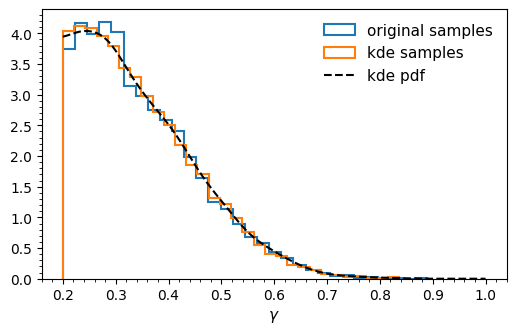

In [ ]:
plt.figure(figsize=(6,3.5))

plt.hist(gamma_samples,bins=30,histtype='step',density=True,linewidth=1.5,label='original samples')
plt.hist(kde_samples,bins=30,histtype='step',density=True,linewidth=1.5,label='kde samples')
plt.plot(x,y,linewidth=1.5,color='k',linestyle='--',label='kde pdf')

plt.minorticks_on()

plt.legend(fontsize=11,frameon=False)

plt.xlabel(r'$\gamma$',fontsize=11)

plt.show()

In [ ]:
log_SD = kde.logpdf(0) + np.log(2) - prior.logpdf(0)
print(log_SD)

[0.92214325]


In [ ]:
np.exp(-logB)

np.float64(0.9599655931076322)

# p-p plot

In [ ]:
## see appendix A.A1 of
## https://arxiv.org/abs/2209.06733

In [ ]:
## priors

def ptform(u):
  xmin = np.array([-5,-4])
  xmax = np.array([5,4])
  theta = uniform.ppf(u,loc=xmin,scale=xmax-xmin)
  return theta

def model(x,alpha,beta):
  out = alpha + beta*x
  return out

In [ ]:
## generate 50 datasets
N = 50
u = np.random.uniform(0,1,size=(N,2))
theta_true = ptform(u)
theta_true.shape

(50, 2)

In [ ]:
Y_true = np.array([model(X,*theta_true_i) for theta_true_i in theta_true])
Y_obs = Y_true + np.random.normal(0,sigma_noise,size=Y_true.shape)

In [ ]:
ndim = 2
nlive = 100

Q = []

for i in tqdm(range(N)):

  Y_obs_i = Y_obs[i]
  theta_true_i = theta_true[i]

  def loglike(theta):
    Y_pred = model(X,*theta)
    out = np.sum(norm.logpdf(x=Y_obs_i,loc=Y_pred,scale=sigma_noise))
    return out

  sampler = NestedSampler(loglike, ptform, ndim, nlive=nlive)
  sampler.run_nested(print_progress=False)
  res = sampler.results
  samples = res.samples_equal()

  Q_i = np.mean( samples <= theta_true_i, axis=0)
  Q.append(Q_i)

Q = np.array(Q)

100%|██████████| 50/50 [02:46<00:00,  3.33s/it]


In [ ]:
x = np.linspace(0,1,100)
y = np.zeros((100,2))
for i in range(100):
  y[i] = np.mean(Q.T<=x[i],axis=1)

In [ ]:
std = np.sqrt(x*(1-x)/N)
ylow = x - 2*std
yhigh = x + 2*std

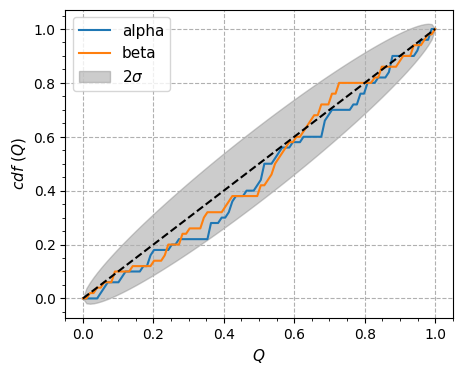

In [ ]:
plt.figure(figsize=(5,4))
plt.plot(x,y,label=['alpha','beta'],linewidth=1.5)
plt.plot(x,x,color='k',linestyle='--',linewidth=1.5)
plt.fill_between(x,ylow,yhigh,color='grey',alpha=0.4,label=r'$2\sigma$')
plt.legend(fontsize=11,frameon=True)
plt.xlabel(r'$Q$',fontsize=11)
plt.ylabel(r'$cdf~(Q)$',fontsize=11)
plt.grid(linestyle='--')
plt.minorticks_on()
plt.show()